# Football Data Analysis - Part 3: Visualization

## Overview
This notebook creates comprehensive visualizations to explore patterns and insights in the football data.

## Contents
- Exploratory data visualizations
- Distribution plots
- Relationship visualizations
- Trend analysis
- Comparative visualizations

## Setup and Data Loading

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

In [ ]:
df = pd.read_csv('../data/processed/cleaned_data.csv')

In [23]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [24]:
df['Player Names'] = df['Player Names'].str.strip().str.title()

# Pisahkan 10 pemain dengan value terbesar & terkecil
top10_players = df.groupby('Player Names')['value'].mean().nlargest(10).index
bottom10_players = df.groupby('Player Names')['value'].mean().nsmallest(10).index

# Filter dataset
top10_df = df[df['Player Names'].isin(top10_players)].copy()
bottom10_df = df[df['Player Names'].isin(bottom10_players)].copy()

# Cek hasil
print("Pemain dengan value tertinggi:", top10_df['Player Names'].unique())
print("Pemain dengan value terendah:", bottom10_df['Player Names'].unique())

Pemain dengan value tertinggi: ['Lionel Messi' 'Jadon Sancho' 'Kai Havertz' 'Neymar' 'Kevin De Bruyne'
 'Raheem Sterling' 'Mohamed Salah' 'Harry Kane' 'Antoine Griezmann'
 'Ansu Fati']
Pemain dengan value terendah: ['Zlatan Ibrahimovic' 'Carlos Fernandez' 'Angel Gomes' 'Marco Mancosu'
 'Fabio Quagliarella' 'Rouwen Hennings' 'Carlos Sanchez' 'Esteban Burgos'
 'Ibrahima Niane' 'Ignatius Ganago']


VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


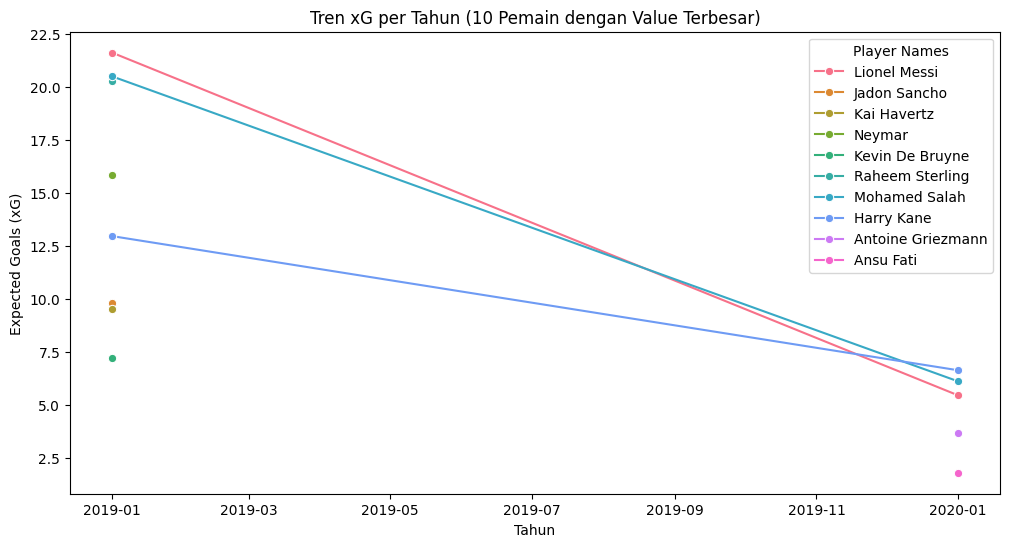

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


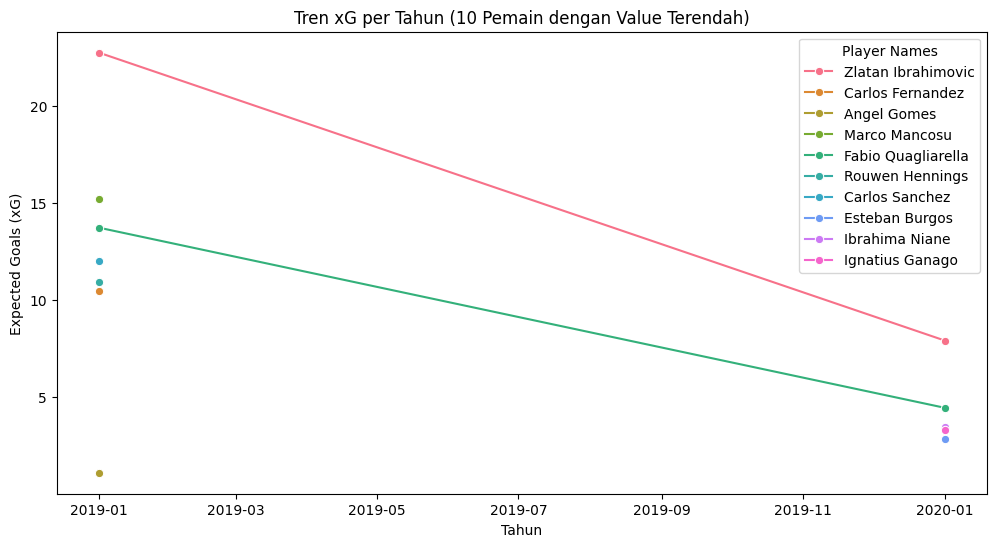

In [25]:
# Line Chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    sns.lineplot(data=data, x='Year', y='xG', hue='Player Names', marker='o')
    plt.title(f'Tren xG per Tahun ({label})')
    plt.xlabel('Tahun')
    plt.ylabel('Expected Goals (xG)')
    plt.legend(title='Player Names', bbox_to_anchor=(1,1))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


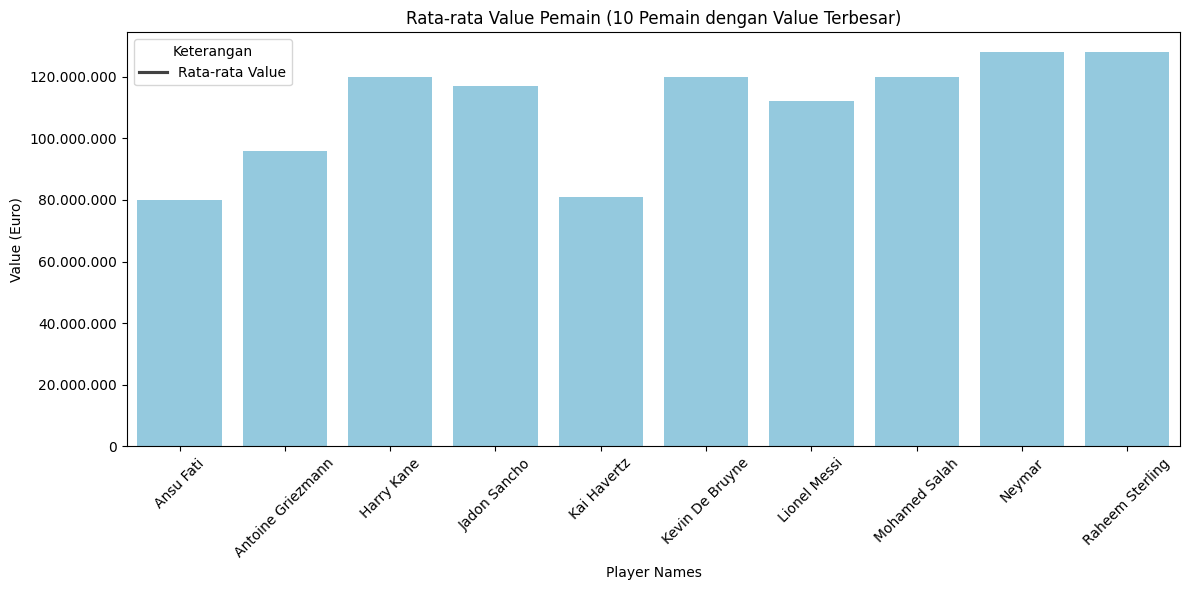

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


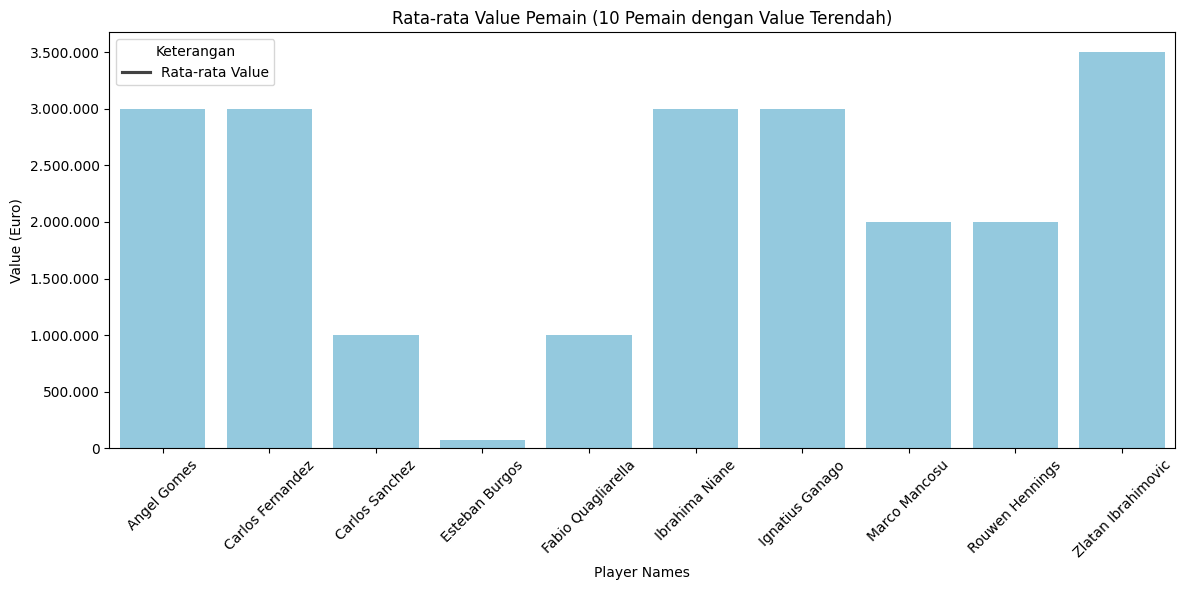

In [26]:
# Bar Chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    avg_value = data.groupby('Player Names')['value'].mean().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_value, x='Player Names', y='value', color='skyblue')

    plt.title(f'Rata-rata Value Pemain ({label})')
    plt.xlabel('Player Names')
    plt.ylabel('Value (Euro)')
    plt.xticks(rotation=45)
    plt.legend(['Rata-rata Value'], title='Keterangan')

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
    )
    plt.tight_layout()
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

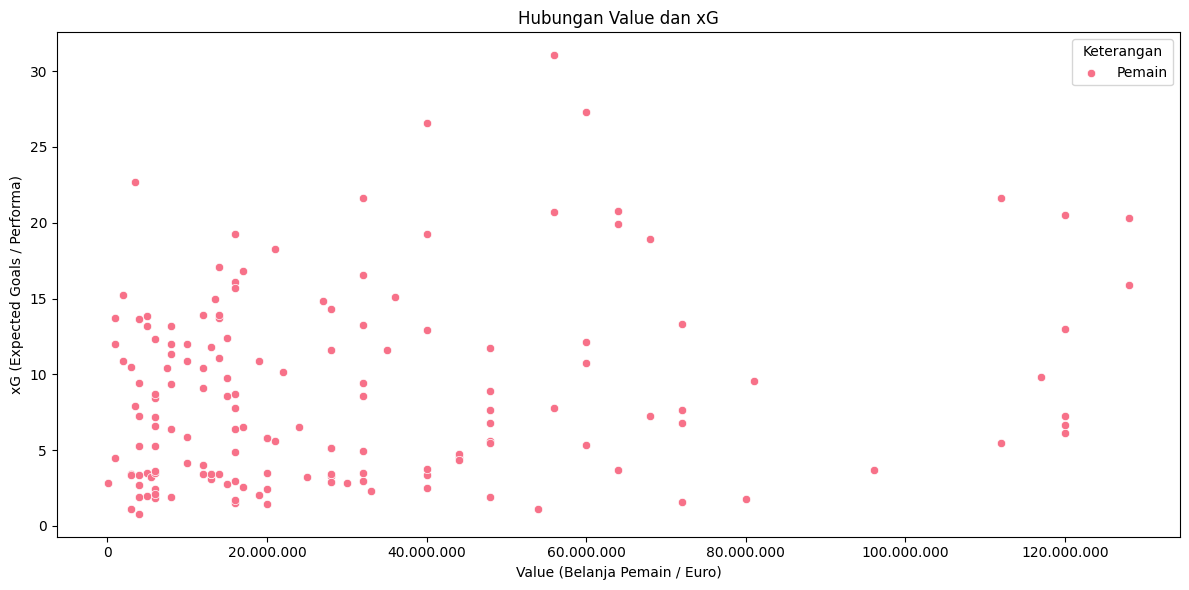

In [27]:
# Scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='value', y='xG')
plt.title('Hubungan Value dan xG')
plt.xlabel('Value (Belanja Pemain / Euro)')
plt.ylabel('xG (Expected Goals / Performa)')
plt.legend(['Pemain'], title='Keterangan')

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)
plt.tight_layout()
plt.show()

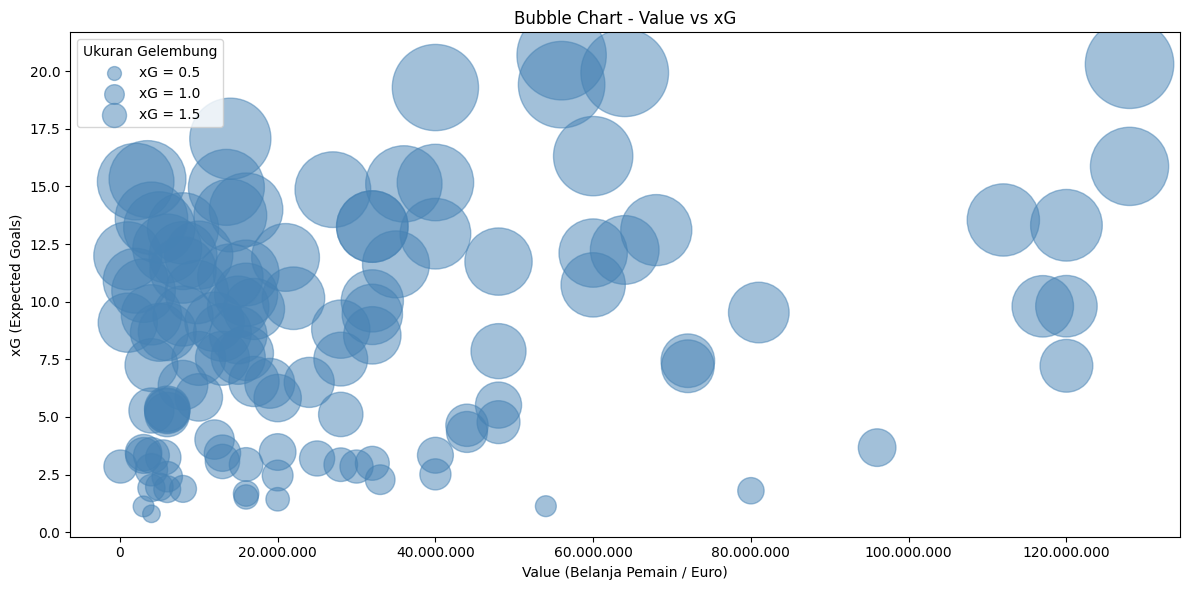

In [28]:
# Bubbe chart
bubble = df.groupby('Player Names')[['value','xG']].mean().reset_index()

plt.figure(figsize=(12,6))
plt.scatter(bubble['value'], bubble['xG'], s=bubble['xG']*200, alpha=0.5, color='steelblue')

plt.title('Bubble Chart - Value vs xG')
plt.xlabel('Value (Belanja Pemain / Euro)')
plt.ylabel('xG (Expected Goals)')
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)
for size in [0.5, 1.0, 1.5]:
    plt.scatter([], [], s=size*200, label=f'xG = {size}', alpha=0.5, color='steelblue')
plt.legend(title='Ukuran Gelembung')

plt.tight_layout()
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


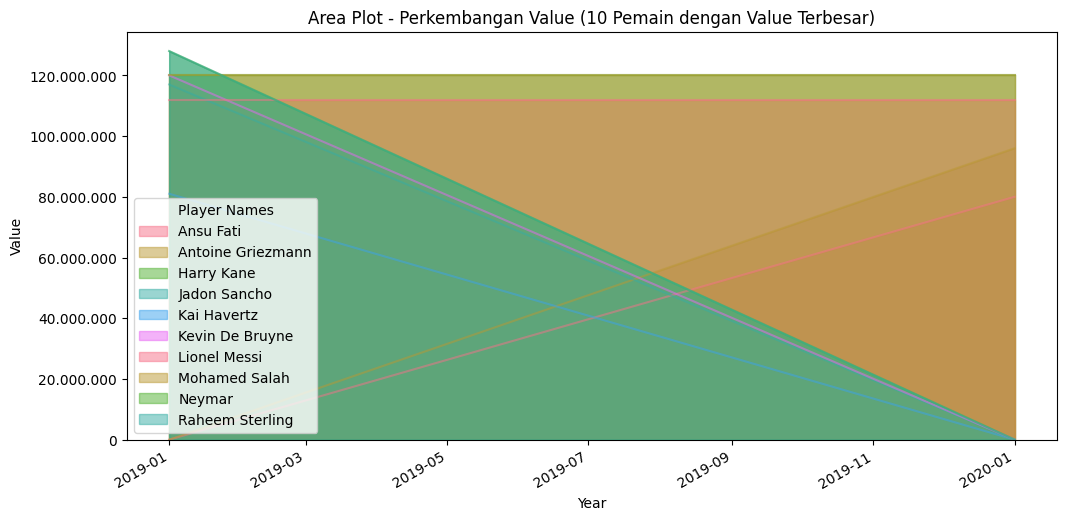

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


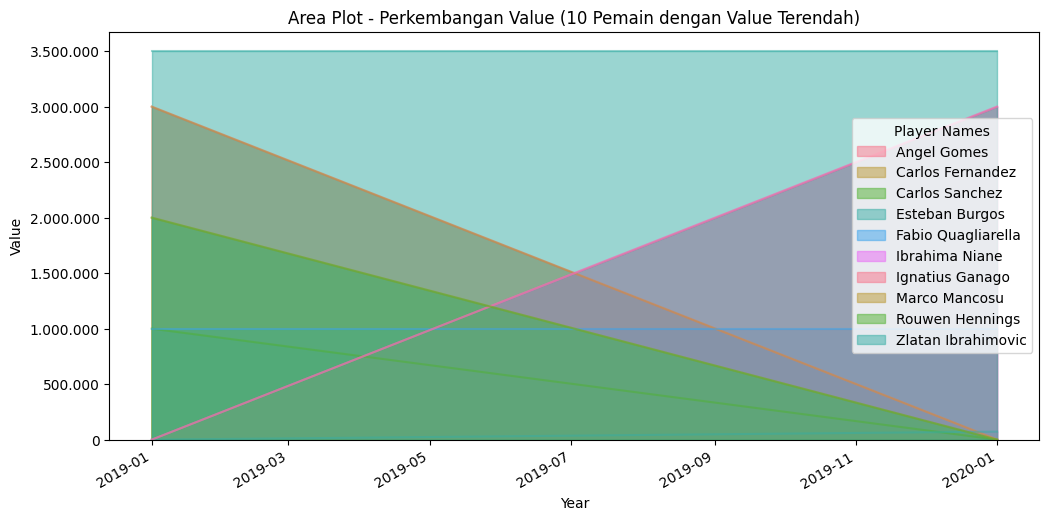

In [29]:
# Area plot
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    pivot_value = data.pivot_table(index='Year', columns='Player Names', values='value', aggfunc='mean')
    pivot_value.plot(kind='area', stacked=False, figsize=(12,6))
    plt.title(f'Area Plot - Perkembangan Value ({label})')
    plt.ylabel('Value')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


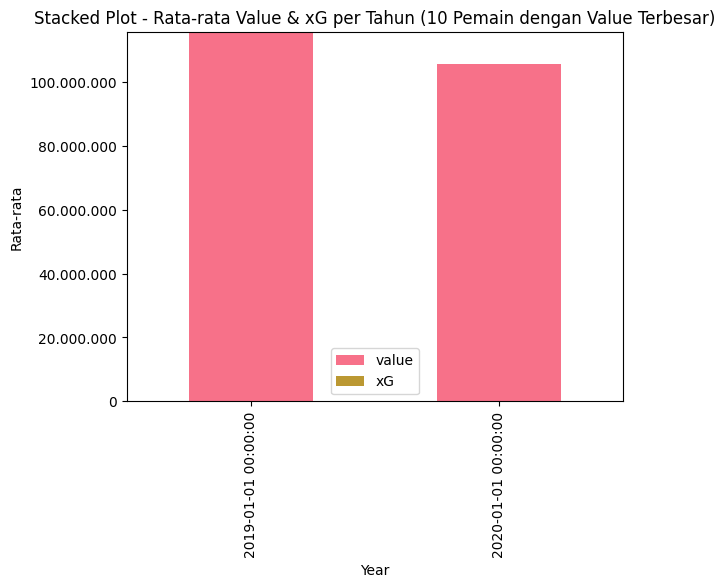

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


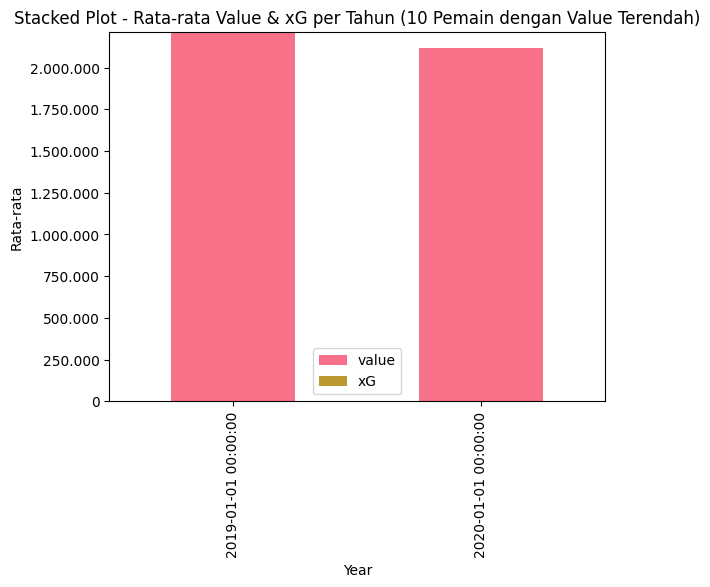

In [30]:
# Stacked plot
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    pivot_stack = data.pivot_table(index='Year', values=['value','xG'], aggfunc='mean')
    pivot_stack.plot(kind='bar', stacked=True)
    plt.title(f'Stacked Plot - Rata-rata Value & xG per Tahun ({label})')
    plt.ylabel('Rata-rata')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


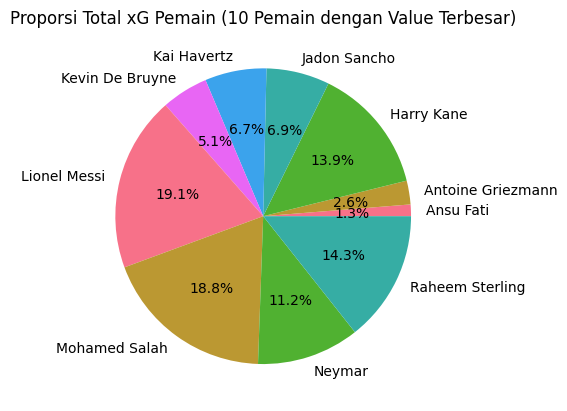

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


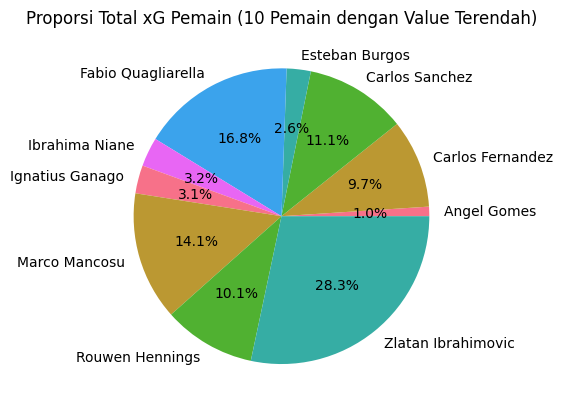

In [31]:
# Pie chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    xg_sum = data.groupby('Player Names')['xG'].sum()
    plt.pie(xg_sum, labels=xg_sum.index, autopct='%1.1f%%')
    plt.title(f'Proporsi Total xG Pemain ({label})')
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

In [32]:
# Tabel (Render Rapi)
def make_visuals(data, label):
    summary = data.groupby('Player Names')[['value','xG']].mean().round(2).reset_index()
    print(f"Rangkuman Rata-rata Value dan xG ({label})")
    display(summary.style.set_table_styles(
        [{'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('text-align', 'center')]},
         {'selector': 'td', 'props': [('text-align', 'center')]}]
    ).set_caption(f"Tabel Rangkuman {label}"))
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

Rangkuman Rata-rata Value dan xG (10 Pemain dengan Value Terbesar)


,Player Names,value,xG
0,Ansu Fati,80000000.000000,1.800000
1,Antoine Griezmann,96000000.000000,3.670000
2,Harry Kane,120000000.000000,9.800000
3,Jadon Sancho,117000000.000000,9.800000
4,Kai Havertz,81000000.000000,9.530000
5,Kevin De Bruyne,120000000.000000,7.220000
6,Lionel Messi,112000000.000000,13.540000
7,Mohamed Salah,120000000.000000,13.320000
8,Neymar,128000000.000000,15.870000
9,Raheem Sterling,128000000.000000,20.300000


Rangkuman Rata-rata Value dan xG (10 Pemain dengan Value Terendah)


,Player Names,value,xG
0,Angel Gomes,3000000.000000,1.120000
1,Carlos Fernandez,3000000.000000,10.480000
2,Carlos Sanchez,1000000.000000,11.990000
3,Esteban Burgos,72500.000000,2.850000
4,Fabio Quagliarella,1000000.000000,9.090000
5,Ibrahima Niane,3000000.000000,3.450000
6,Ignatius Ganago,3000000.000000,3.330000
7,Marco Mancosu,2000000.000000,15.210000
8,Rouwen Hennings,2000000.000000,10.910000
9,Zlatan Ibrahimovic,3500000.000000,15.320000


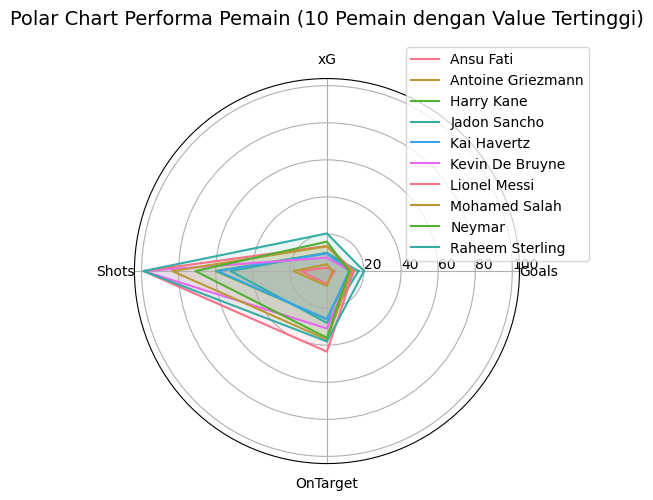

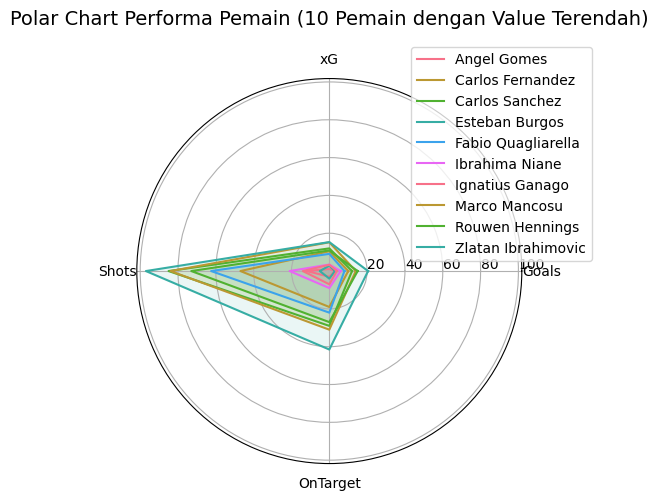

In [33]:
# Polar Chart
def polar_chart(data, label):
    # Pilih beberapa metrik performa
    metrics = ['Goals', 'xG', 'Shots', 'OnTarget']
    avg_data = data.groupby('Player Names')[metrics].mean()
    top10 = avg_data.head(10)

    # Hitung sudut (angle) untuk setiap variabel
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(5, 5))
    ax = plt.subplot(111, polar=True)

    for idx, (player, row) in enumerate(top10.iterrows()):
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=player)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_rlabel_position(0)
    plt.title(f'Polar Chart Performa Pemain ({label})', size=14, pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()
polar_chart(top10_df, "10 Pemain dengan Value Tertinggi")
polar_chart(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


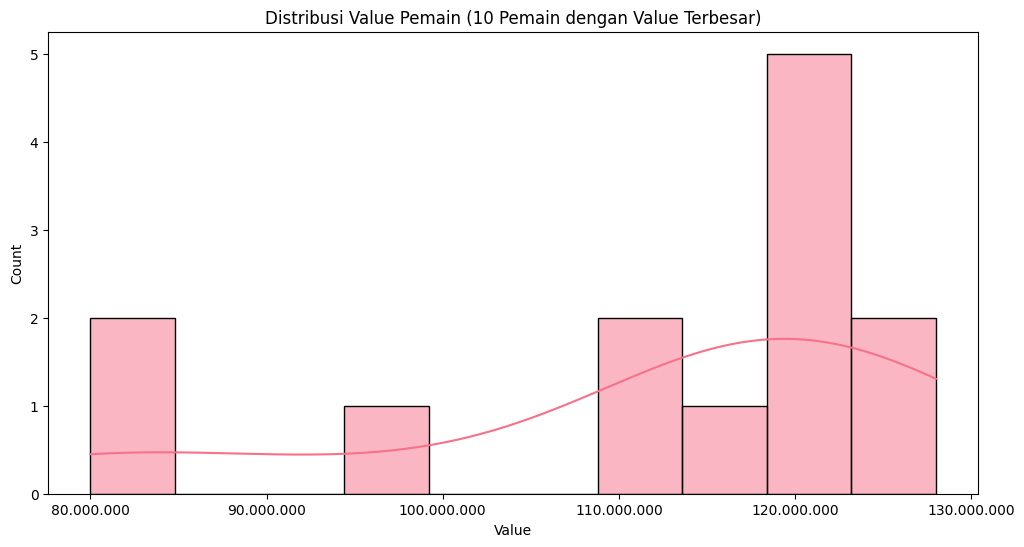

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


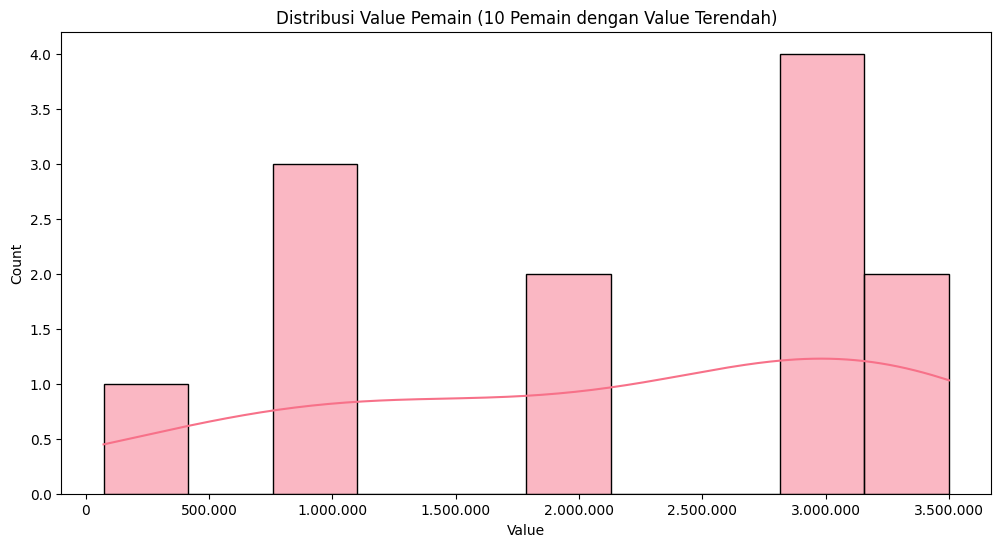

In [34]:
# Histogram
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    sns.histplot(data['value'], bins=10, kde=True)
    plt.title(f'Distribusi Value Pemain ({label})')
    plt.xlabel('Value')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

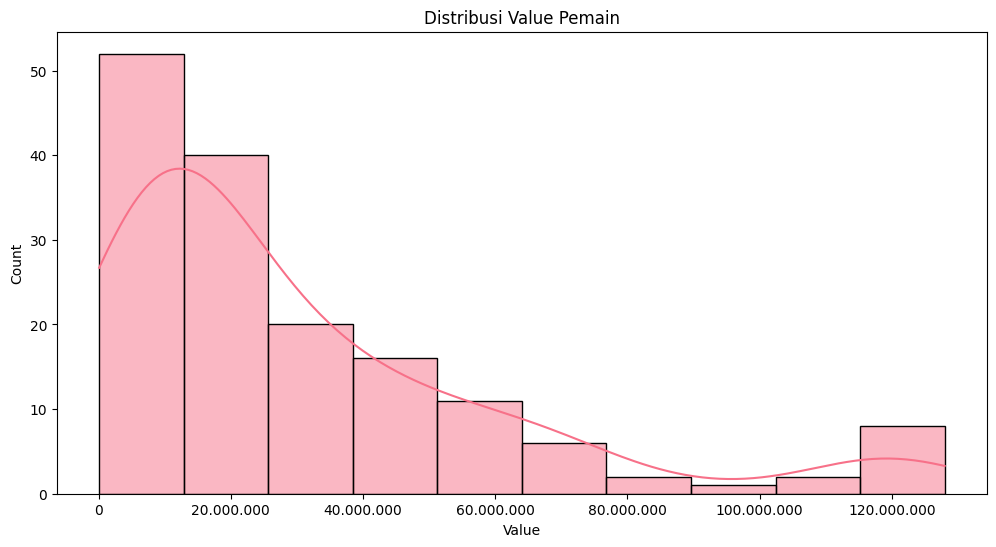

In [35]:
# Histogram
plt.figure(figsize=(12,6))
sns.histplot(df['value'], bins=10, kde=True)
plt.title('Distribusi Value Pemain')
plt.xlabel('Value')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


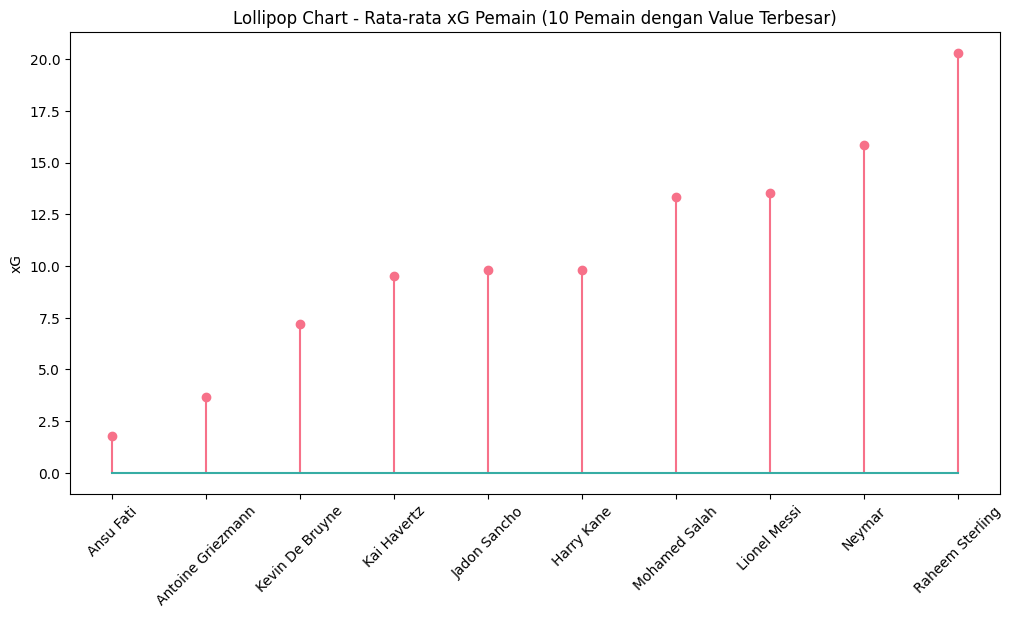

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


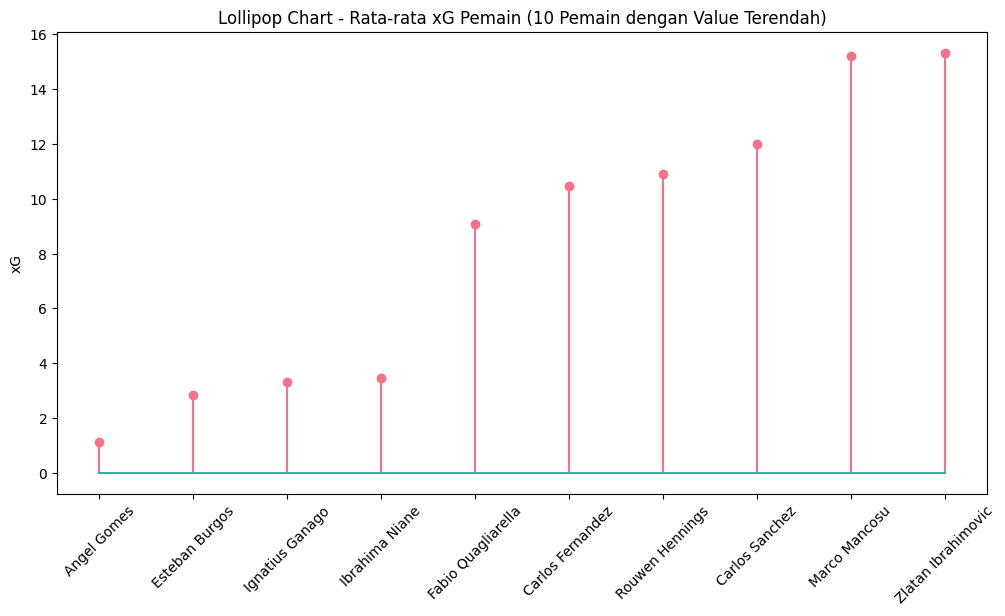

In [36]:
# Lollipop
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    mean_xg = data.groupby('Player Names')['xG'].mean().sort_values()
    plt.stem(mean_xg.index, mean_xg.values)
    plt.title(f'Lollipop Chart - Rata-rata xG Pemain ({label})')
    plt.xticks(rotation=45)
    plt.ylabel('xG')
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

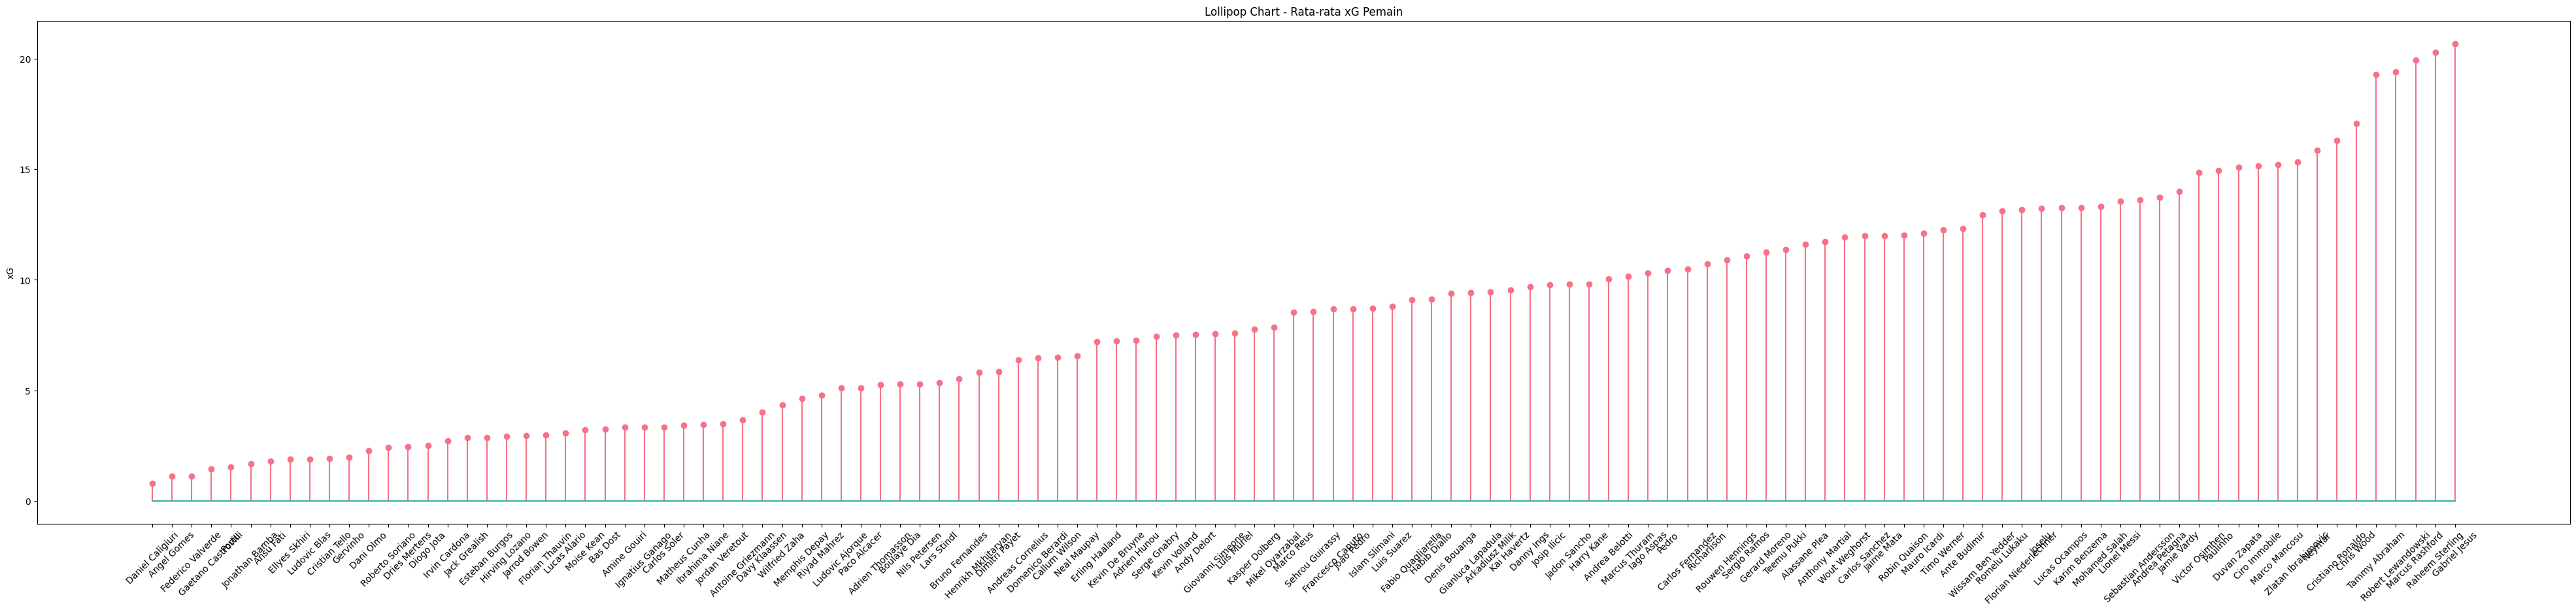

In [37]:
# Lollipop chart
plt.figure(figsize=(50,10))
mean_xg = df.groupby('Player Names')['xG'].mean().sort_values()
plt.stem(mean_xg.index, mean_xg.values)
plt.title('Lollipop Chart - Rata-rata xG Pemain')
plt.xticks(rotation=45)
plt.ylabel('xG')
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


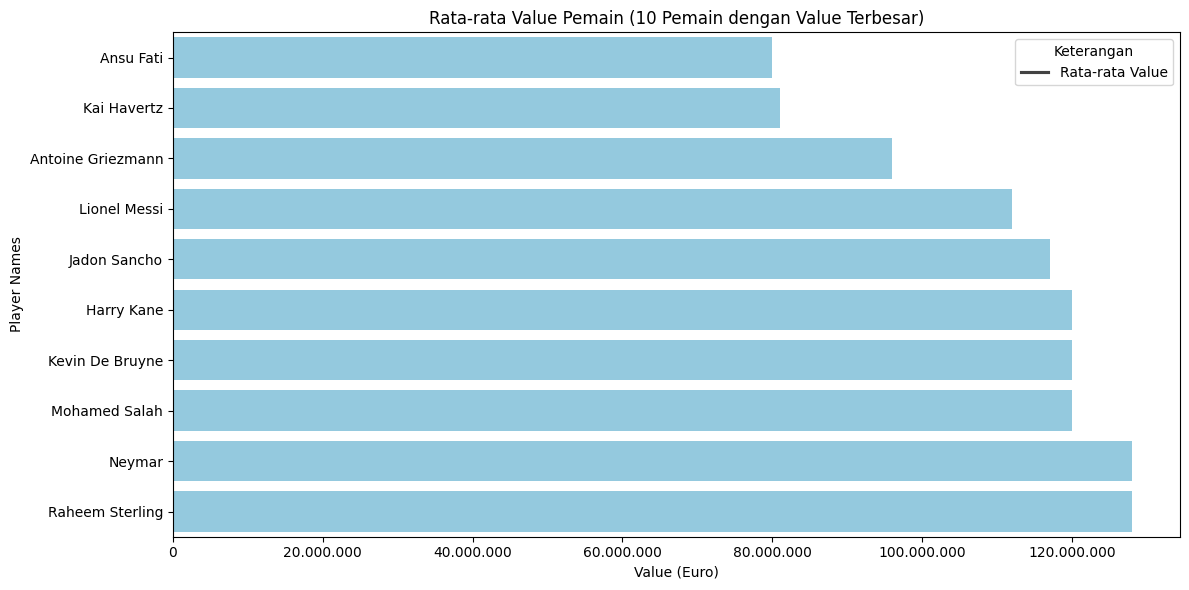

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


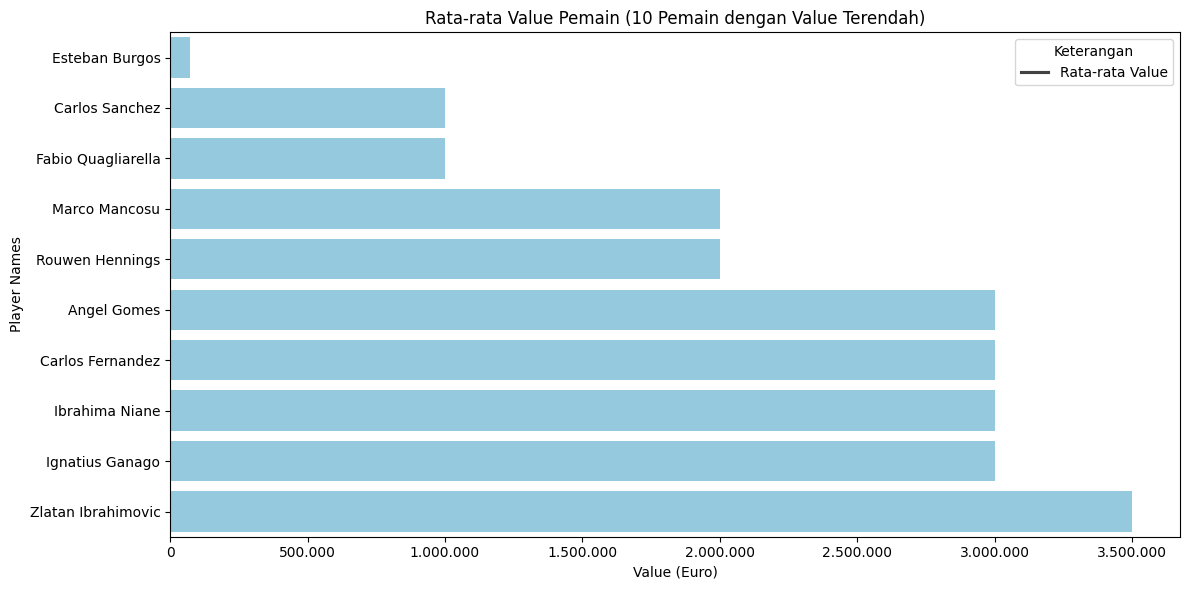


VISUALISASI 2: SCATTER PLOT (Hubungan Value dan Performa)


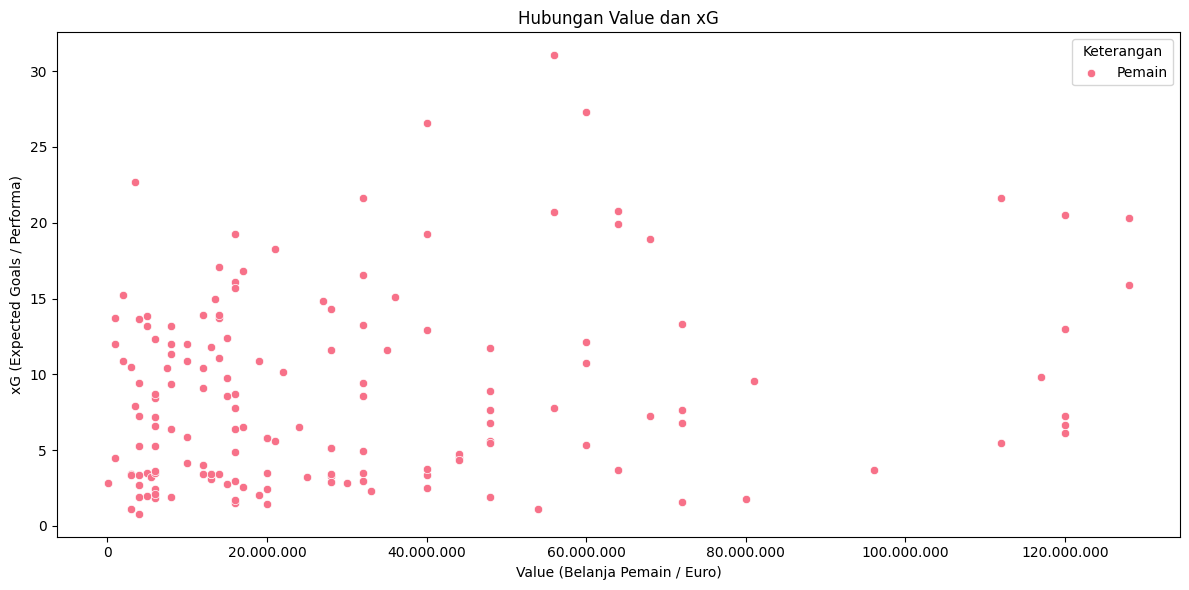


VISUALISASI 3: BUBBLE CHART (Value vs Performa dengan Ukuran Gelembung)


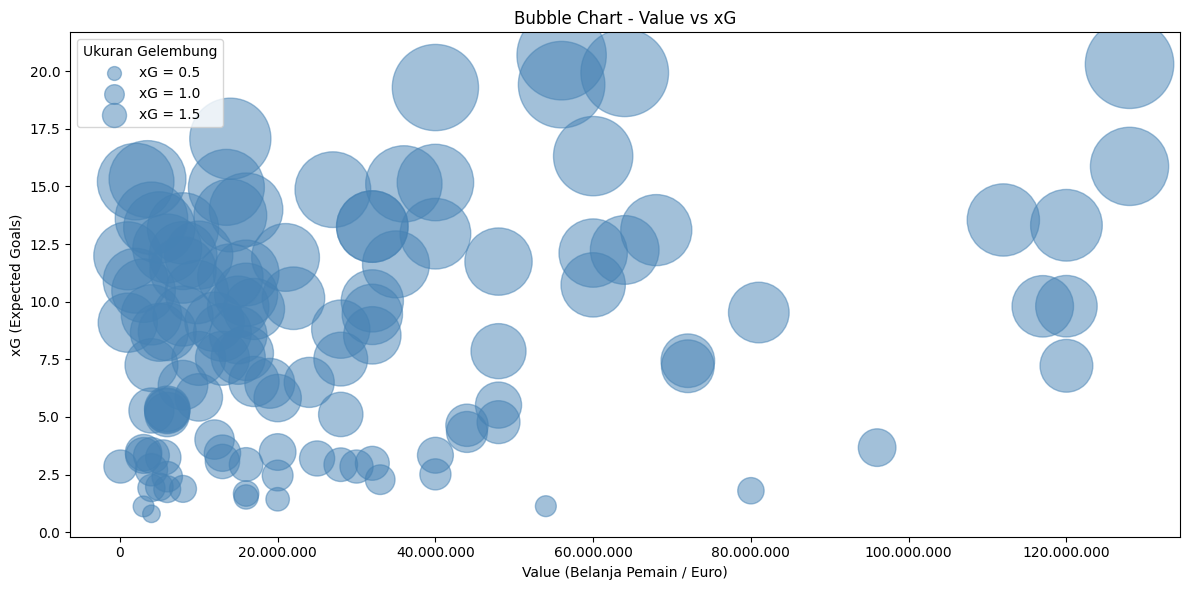

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. BAR CHART (Horizontal)
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    avg_value = data.groupby('Player Names')['value'].mean().reset_index()
    avg_value = avg_value.sort_values('value', ascending=True)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_value, x='value', y='Player Names', color='skyblue')
    plt.title(f'Rata-rata Value Pemain ({label})')
    plt.xlabel('Value (Euro)')
    plt.ylabel('Player Names')
    plt.legend(['Rata-rata Value'], title='Keterangan')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.tight_layout()
    plt.show()

# 2. SCATTER PLOT
def scatter_plot(df):
    print("\nVISUALISASI 2: SCATTER PLOT (Hubungan Value dan Performa)")
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x='value', y='xG')
    plt.title('Hubungan Value dan xG')
    plt.xlabel('Value (Belanja Pemain / Euro)')
    plt.ylabel('xG (Expected Goals / Performa)')
    plt.legend(['Pemain'], title='Keterangan')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.tight_layout()
    plt.show()

# 3. BUBBLE CHART
def bubble_chart(df):
    print("\nVISUALISASI 3: BUBBLE CHART (Value vs Performa dengan Ukuran Gelembung)")
    bubble = df.groupby('Player Names')[['value','xG']].mean().reset_index()

    plt.figure(figsize=(12,6))
    plt.scatter(bubble['value'], bubble['xG'], s=bubble['xG']*200, alpha=0.5, color='steelblue')
    plt.title('Bubble Chart - Value vs xG')
    plt.xlabel('Value (Belanja Pemain / Euro)')
    plt.ylabel('xG (Expected Goals)')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    for size in [0.5, 1.0, 1.5]:
      plt.scatter([], [], s=size*200, label=f'xG = {size}', alpha=0.5, color='steelblue')
      plt.legend(title='Ukuran Gelembung')
    plt.tight_layout()
    plt.show()

make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")
scatter_plot(df)
bubble_chart(df)